# Milestone 1 — EDA

In [8]:
# imports
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
pd.set_option("display.max_colwidth", 200)

In [2]:
# load train and test
data_dir = Path("../data")
train = pd.read_csv(data_dir / "train.csv")
test = pd.read_csv(data_dir / "test.csv")

In [3]:
# shapes and head
print(train.shape, test.shape)
train.head()

(2000, 8) (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a histo...,"Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future invol...","Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is so...",Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future is predetermined. Human beings do not have free...,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this illusion and are guided by a higher power.",B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively ea...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively di...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively di...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively ea...,Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fission reactions. This method is relatively e...,A
2,3,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.,Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a histo...,"Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future invol...","Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is so...",Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future is predetermined. Human beings do not have free...,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this illusion and are guided by a higher power.",B
4,5,"Identify the correct statement: What is the concept of simultaneity in Einstein's book, Relativity? carefully.","Simultaneity is relative, meaning that two events that appear simultaneous to an observer in a particular inertial reference frame need not be judged as simultaneous by a second observer in a diff...","Simultaneity is relative, meaning that two events that appear simultaneous to

In [4]:
# train answer label distribution
train["answer"].value_counts(normalize=True).round(4)

answer
B    0.2450
C    0.2295
A    0.1845
D    0.1790
E    0.1620
Name: proportion, dtype: float64

count    2000.00
mean      117.67
std        44.41
min        19.00
25%        87.75
50%       111.00
75%       141.00
max       337.00
Name: prompt, dtype: float64


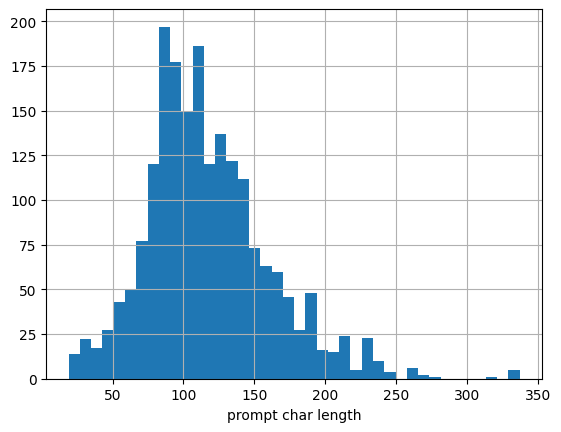

In [5]:
# prompt length distribution
print(train["prompt"].str.len().describe().round(2))
train["prompt"].str.len().hist(bins=40)
plt.xlabel("prompt char length")
plt.show()

In [6]:
# option length distribution per column
opt_cols = ["A", "B", "C", "D", "E"]
opt_lens = pd.DataFrame({c: train[c].str.len() for c in opt_cols})
opt_lens.describe().round(2)

,A,B,C,D,E
count,2000.00,2000.00,2000.00,2000.00,2000.00
mean,164.09,166.62,167.23,162.56,164.23
std,105.68,113.83,105.72,104.12,107.78
min,1.00,2.00,2.00,1.00,2.00
25%,86.00,82.00,88.00,91.00,84.00
50%,143.00,151.00,158.00,141.00,144.00
75%,234.00,222.00,224.00,231.00,224.00
max,472.00,662.00,530.00,450.00,587.00


In [7]:
# longest option inspection
flat = opt_lens.stack()
top_idx = flat.idxmax()
print(top_idx, int(flat.max()))
print(train.loc[top_idx[0], top_idx[1]])

(176, 'B') 662
The Milky Way galaxy has a supermassive black hole at its center because the star S14 follows an elliptical orbit with a period of 15.2 years and a pericenter of 17 light-hours from the center of the central object. From the motion of star S14, the object's mass can be estimated as 4.0 million M☉, or about 7.96×1036 kg. The radius of the central object must be less than 17 light-hours, because otherwise S14 would collide with it. Observations of the star S2 indicate that the radius is no more than 6.25 light-hours, about the diameter of Uranus' orbit. No known astronomical object other than a black hole can contain 4.0 million M☉ in this volume of space.


In [9]:
# candidate wrapper prefix frequency in raw prompts
from src.normalize import _PREFIXES
prefix_freq = pd.DataFrame({
    "train": [int(train["prompt"].str.lstrip().str.startswith(p, na=False).sum()) for p in _PREFIXES],
    "test": [int(test["prompt"].str.lstrip().str.startswith(p, na=False).sum()) for p in _PREFIXES],
}, index=_PREFIXES)
prefix_freq["total"] = prefix_freq["train"] + prefix_freq["test"]
print("train rows with no known prefix:", len(train) - prefix_freq["train"].sum())
print("test rows with no known prefix:", len(test) - prefix_freq["test"].sum())
prefix_freq

train rows with no known prefix: 200
test rows with no known prefix: 200


,train,test,total
Pick the best possible answer:,316,44,360
Select the most accurate option:,309,50,359
Determine the correct option:,299,56,355
Identify the correct statement:,302,47,349
Choose the correct answer:,292,56,348
Which of the following is correct?,282,47,329


In [10]:
# candidate wrapper suffix frequency in raw prompts
from src.normalize import _SUFFIXES
suffix_freq = pd.DataFrame({
    "train": [int(train["prompt"].str.rstrip().str.endswith(s, na=False).sum()) for s in _SUFFIXES],
    "test": [int(test["prompt"].str.rstrip().str.endswith(s, na=False).sum()) for s in _SUFFIXES],
}, index=_SUFFIXES)
suffix_freq["total"] = suffix_freq["train"] + suffix_freq["test"]
print("train rows with no known suffix:", len(train) - suffix_freq["train"].sum())
print("test rows with no known suffix:", len(test) - suffix_freq["test"].sum())
suffix_freq

train rows with no known suffix: 538
test rows with no known suffix: 272


,train,test,total
among the listed options.,388,56,444
based on the given context.,376,58,434
from the following choices.,369,52,421
carefully.,329,62,391


In [11]:
# import normalize_stem and verify on synthetic samples
from src.normalize import normalize_stem
samples = [
    "Pick the best possible answer: What is 2 + 2?",
    "What is 2 + 2? among the listed options.",
    "Pick the best possible answer: What is 2 + 2? among the listed options.",
    "Pick the best possible answer: Choose the correct answer: What is 2 + 2?",
    "What is the capital of France?",
]
for s in samples:
    print(repr(normalize_stem(s)))

'What is 2 + 2?'
'What is 2 + 2?'
'What is 2 + 2?'
'What is 2 + 2?'
'What is the capital of France?'


In [12]:
# normalization sanity check on actual rows
for i in [0, 1, 2, 500, 1000, 1500]:
    raw = train.loc[i, "prompt"]
    norm = normalize_stem(raw)
    print("raw :", raw[:100])
    print("norm:", norm[:100])
    print()

raw : Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and 
norm: What is Martin Heidegger's view on the relationship between time and human existence?

raw : What is accelerator-based light-ion fusion?
norm: What is accelerator-based light-ion fusion?

raw : Determine the correct option: What is the term used in astrophysics to describe light-matter interac
norm: What is the term used in astrophysics to describe light-matter interactions resulting in energy shif

raw : Choose the correct answer: What is the Maxwell's Demon thought experiment? among the listed options.
norm: What is the Maxwell's Demon thought experiment?

raw : Select the most accurate option: What is the Landau-Lifshitz-Gilbert equation used for in physics? b
norm: What is the Landau-Lifshitz-Gilbert equation used for in physics?

raw : Identify the correct statement: Which of the following statements is true about the categorization o
norm: Which of the following statem

In [13]:
# attach normalized_stem column to train and test
train["stem"] = train["prompt"].apply(normalize_stem)
test["stem"] = test["prompt"].apply(normalize_stem)
deltas = train["prompt"].str.len() - train["stem"].str.len()
print("avg chars removed by normalization (train):", round(deltas.mean(), 2))
print("max chars removed:", int(deltas.max()))
print("rows unchanged by normalization (train):", int((deltas == 0).sum()))
train[["prompt", "stem"]].head()

avg chars removed by normalization (train): 45.47
max chars removed: 63
rows unchanged by normalization (train): 200


,prompt,stem
0,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,What is Martin Heidegger's view on the relationship between time and human existence?
1,What is accelerator-based light-ion fusion?,What is accelerator-based light-ion fusion?
2,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.,What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field?
3,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.,What is Martin Heidegger's view on the relationship between time and human existence?
4,"Identify the correct statement: What is the concept of simultaneity in Einstein's book, Relativity? carefully.","What is the concept of simultaneity in Einstein's book, Relativity?"


In [14]:
# unique normalized stems in train
train["stem"].nunique()

252

In [15]:
# unique normalized stems in test
test["stem"].nunique()

228

In [16]:
# train-test stem overlap quantification
train_stems = set(train["stem"])
test_stems = set(test["stem"])
print("train unique stems:", len(train_stems))
print("test unique stems:", len(test_stems))
print("test stems also in train:", len(test_stems & train_stems))
print("test stems not in train:", len(test_stems - train_stems))
print("test rows covered by overlap:", int(test["stem"].isin(train_stems).sum()))

train unique stems: 252
test unique stems: 228
test stems also in train: 228
test stems not in train: 0
test rows covered by overlap: 500


In [17]:
# multi-occurrence stem answer-label consistency check
sizes = train.groupby("stem").size()
n_answers = train.groupby("stem")["answer"].nunique()
multi = sizes[sizes > 1].index
print("multi-occurrence stems:", len(multi))
print("inconsistent stems:", int((n_answers.loc[multi] > 1).sum()))
print("consistent stems:", int((n_answers.loc[multi] == 1).sum()))

multi-occurrence stems: 222
inconsistent stems: 0
consistent stems: 222


In [18]:
# stem to answer label lookup from train
stem_to_answer = train.drop_duplicates("stem").set_index("stem")["answer"].to_dict()
coverage = int(test["stem"].isin(stem_to_answer).sum())
print("stem-to-answer map size:", len(stem_to_answer))
print("test rows with stem in lookup:", coverage, "/", len(test))
assert coverage == len(test), "Some test stems missing from train lookup"

stem-to-answer map size: 252
test rows with stem in lookup: 500 / 500


In [19]:
# identical-option match count per test row
opt_cols = ["A", "B", "C", "D", "E"]
train_signatures = set()
for _, row in train.iterrows():
    sig = (row["stem"], frozenset({row[c] for c in opt_cols}))
    train_signatures.add(sig)
identity_mask = test.apply(
    lambda r: (r["stem"], frozenset({r[c] for c in opt_cols})) in train_signatures,
    axis=1,
)
print("identity-match test rows:", int(identity_mask.sum()))
print("paraphrase-residual test rows:", int((~identity_mask).sum()))

identity-match test rows: 455
paraphrase-residual test rows: 45


In [20]:
# identical-match vs paraphrased-option breakdown
test["match_type"] = identity_mask.map({True: "identity", False: "paraphrase"})
breakdown = test["match_type"].value_counts()
print(breakdown)
print((breakdown / len(test)).round(4))

match_type
identity      455
paraphrase     45
Name: count, dtype: int64
match_type
identity      0.91
paraphrase    0.09
Name: count, dtype: float64


In [22]:
# paraphrased-option rows side-by-side inspection
paraphrase_rows = test[test["match_type"] == "paraphrase"].head(3)
for idx, row in paraphrase_rows.iterrows():
    print("test row", idx)
    print("stem:", row["stem"][:80])
    print("test options:")
    for c in opt_cols:
        print(f"  {c}: {str(row[c])[:80]}")
    train_match = train[train["stem"] == row["stem"]].iloc[0]
    print("train options:")
    for c in opt_cols:
        print(f"  {c}: {str(train_match[c])[:80]}")
    print("train answer label:", train_match["answer"])
    print()

test row 5
stem: What is the Evans balance?
test options:
  A: The Evans balance is a mechanism used to measure the change in weight of a sampl
  B: The Evans balance is a framework used to measure the dependence of the NMR frequ
  C: The Evans balance is a mechanism used to measure the magnetic field distortion a
  D: The Evans balance is a structure used to measure the susceptibility of a sample 
  E: The Evans balance is a structure used to measure the magnetic susceptibility of 
train options:
  A: The Evans balance is a framework used to measure the change in weight of a sampl
  B: The Evans balance is a mechanism used to measure the dependence of the NMR frequ
  C: The Evans balance is a framework used to measure the magnetic field distortion a
  D: The Evans balance is a structure used to measure the susceptibility of a sample 
  E: The Evans balance is a framework used to measure the magnetic susceptibility of 
train answer label: D

test row 22
stem: Who was Giordano Bruno?
te

In [23]:
# placeholder strategy comparison: stem-label vs fuzzy-text-match
from difflib import SequenceMatcher

def fuzzy_best_label(test_row, train_correct_text):
    scores = [(c, SequenceMatcher(None, train_correct_text, str(test_row[c])).ratio()) for c in opt_cols]
    return max(scores, key=lambda x: x[1])[0]

paraphrase_rows = test[test["match_type"] == "paraphrase"]
agree_count = 0
for _, row in paraphrase_rows.iterrows():
    tm = train[train["stem"] == row["stem"]].iloc[0]
    correct_text = tm[tm["answer"]]
    fuzzy_label = fuzzy_best_label(row, correct_text)
    if fuzzy_label == tm["answer"]:
        agree_count += 1

n = len(paraphrase_rows)
print(f"paraphrase rows: {n}")
print(f"fuzzy label agrees with train answer label: {agree_count}/{n} = {agree_count/n:.4f}")

paraphrase rows: 45
fuzzy label agrees with train answer label: 43/45 = 0.9556
